# Building a Multi Layer Perceptron for Diabetes Risk Prediction

Welcome to your Deep Learning project! In this notebook, you’ll take on the role of a data scientist building a neural network that predicts diabetes risk, helping healthcare providers prioritize patients for diagnostic testing.

### What you'll build

By completing this notebook, you will _(demonstrate ability to)_:

- Design MLP architectures with appropriate depth, width, and activations
- Preprocess data with proper splitting, normalization, and batching
- Implement training loops with forward/backward passes and optimization
- Apply evaluation metrics suited for specialized applications
- Diagnose overfitting/underfitting using loss curves
- Improve models systematically through hyperparameter tuning and regularization
- Interpret performance in context with actionable recommendations

**Dataset**: [CDC Diabetes Health Indicators](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset) (balanced subset of 50,000 patients, 21 features)  
**Estimated time**: 5-6 hours  

> *Have more questions about the project?* Review the [README.md](../README.md) for full project context, setup instructions, and deliverables.

### Ready to get started?

This notebook is divided into 8 sections: 

```Setup → Data Loading → Data Preprocessing → Model Design → Model Training → Model Evaluation → Model Improvements → Conclusion```

Follow them in sequence to complete your project!

---
## Step 0: Set up the environment

Let's begin by importing the necessary libraries and setting up our environment for reproducibility.

In [1]:
# Standard library imports
import numpy as np
import pandas as pd
import numbers
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List, Optional

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully!
PyTorch version: 2.12.1+cu130


In [2]:
# Set random seeds for reproducibility
# This ensures that your results are consistent across runs
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
    
print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 42


> **Why reproducibility matters**: Setting random seeds ensures that your results are consistent across different runs. This is critical for debugging and comparing different model configurations. 
> <br>In production systems, reproducibility helps with model versioning and validation.

In [3]:
# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Set cuDNN to deterministic mode for reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Using device: cpu


> **Moving execution to device**: Transferring your model and tensors to the GPU can drastically improve performance.  
> <br>Use `.to(device)` for models and tensors to ensure everything runs on the same hardware.  
> <br>*Example:*  
> ```model = model.to(device)```   
> ```inputs = inputs.to(device)```  
> <br>**Note**: Mixing CPU and GPU tensors in operations will raise errors.

---
## Step 1: Load and explore the dataset

Understanding your data is the first critical step in any deep learning project. In this step, you will load the dataset and perform exploratory data analysis to understand your dataset.

The CDC diabetes dataset is provided as a CSV file in the [`data/`](../data/) directory. You'll use [pandas](https://pandas.pydata.org/) to load it into a DataFrame for analysis.

### 1.1 Load the dataset

The dataset contains health indicators from the CDC's Behavioral Risk Factor Surveillance System. Each row represents a patient with 21 health-related features and a binary diabetes diagnosis.

In [4]:
# Load the diabetes dataset
df = pd.read_csv('data/diabetes_data.csv')

print(f"Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (50000, 22)

First few rows:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,27,1,0,0,1,0,1,...,0,2,0,0,0,1,12,6,8,1
1,0,0,1,30,0,0,0,1,1,1,...,0,1,0,0,0,1,8,5,5,0
2,1,0,1,33,0,0,0,1,1,1,...,0,3,0,0,0,0,7,5,6,0
3,1,1,1,25,0,0,0,1,1,1,...,0,1,0,0,0,1,9,6,4,0
4,1,1,1,29,1,0,1,0,0,1,...,0,5,3,10,1,0,9,4,2,1


In [5]:
# TODO 1: Display basic dataset information
# Display DataFrame info to understand structure, types, and missing values

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   HighBP                50000 non-null  int64
 1   HighChol              50000 non-null  int64
 2   CholCheck             50000 non-null  int64
 3   BMI                   50000 non-null  int64
 4   Smoker                50000 non-null  int64
 5   Stroke                50000 non-null  int64
 6   HeartDiseaseorAttack  50000 non-null  int64
 7   PhysActivity          50000 non-null  int64
 8   Fruits                50000 non-null  int64
 9   Veggies               50000 non-null  int64
 10  HvyAlcoholConsump     50000 non-null  int64
 11  AnyHealthcare         50000 non-null  int64
 12  NoDocbcCost           50000 non-null  int64
 13  GenHlth               50000 non-null  int64
 14  MentHlth              50000 non-null  int64
 15  PhysHlth              50000 non-null  int64
 16  DiffWalk       

### 1.2 Understanding the features

The dataset contains 21 health and lifestyle indicators. Let's examine what each feature represents and its clinical significance:

| Feature | Description | Type | Clinical Significance |
|---------|-------------|------|----------------------|
| **Diabetes_binary** | Diabetes diagnosis | Binary (0/1) | **Target variable** |
| HighBP | High blood pressure diagnosis | Binary | Strong risk factor |
| HighChol | High cholesterol diagnosis | Binary | Cardiovascular risk |
| CholCheck | Cholesterol check in past 5 years | Binary | Preventive care indicator |
| BMI | Body Mass Index | Continuous | Key obesity indicator |
| Smoker | Smoking history | Binary | Lifestyle risk factor |
| Stroke | History of stroke | Binary | Cardiovascular complication |
| HeartDiseaseorAttack | Coronary heart disease or MI | Binary | Cardiovascular complication |
| PhysActivity | Physical activity in past 30 days | Binary | Protective factor |
| Fruits | Fruit consumption (1+ per day) | Binary | Dietary indicator |
| Veggies | Vegetable consumption (1+ per day) | Binary | Dietary indicator |
| HvyAlcoholConsump | Heavy alcohol consumption | Binary | Lifestyle risk factor |
| AnyHealthcare | Any healthcare coverage | Binary | Access to care |
| NoDocbcCost | Could not see doctor due to cost | Binary | Healthcare barrier |
| GenHlth | General health (1-5 scale) | Ordinal | Self-reported health status |
| MentHlth | Mental health (days not good in past 30) | Continuous | Mental health indicator |
| PhysHlth | Physical health (days not good in past 30) | Continuous | Physical health indicator |
| DiffWalk | Difficulty walking or climbing stairs | Binary | Mobility indicator |
| Sex | Biological sex | Binary | Demographic factor |
| Age | Age category (1-13) | Ordinal | Strong demographic predictor |
| Education | Education level (1-6) | Ordinal | Socioeconomic indicator |
| Income | Income level (1-8) | Ordinal | Socioeconomic indicator |

For a complete overview of the dataset, refer to the [`data/data_dictionary.md`](data/data_dictionary.md) file.

> **Feature dictionaries in the real-world**: In practice, you'll often create these yourself by interviewing domain experts. Always document: feature meaning, type, measurement method, and known limitations.
> <br> Think of the feature dictionary as your model's "instruction manual"; without it, even brilliant ML work becomes unusable in production.


### 1.3 Perform exploratory data analysis (EDA)

Understanding your data involves checking for missing values, reviewing feature distributions, understanding target variable distribution, and identifying patterns that will inform your modeling decisions.

In [6]:
# TODO 2: Check for missing values in the dataset
# Check each column for null/NaN values

missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")


Missing values per column:
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

Total missing values: 0


> **Handling missing values** Even though this dataset has no missing values, it's crucial to check for them in any data workflow since they can disrupt model training, bias results, or break computations. Common strategies to handle missing values include:
>   - *Removal:* Drop rows or columns if the proportion of missing data is small.  
>   - *Imputation:* Fill with mean, median, mode, or domain-specific defaults.  
>   - *Model-based methods:* Predict missing values using other features.  
> Always make sure to also analyze *why* data is missing: it can reveal data collection issues or hidden patterns!  
>
> *Reference:* [ Working with missing data in Pandas](https://pandas.pydata.org/docs/user_guide/missing_data.html)


Target Variable Distribution:
No Diabetes (0): 25,000 (50.00%)
Diabetes (1): 25,000 (50.00%)


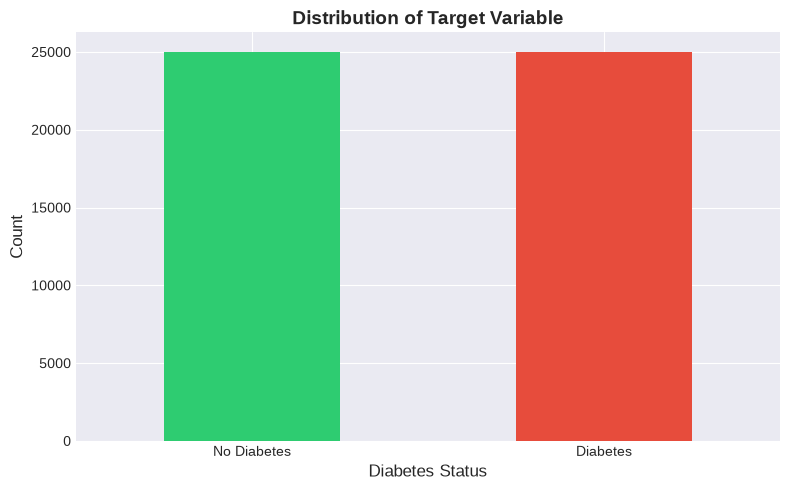

In [7]:
# TODO 3: Analyze and visualize the target variable distribution

target_distribution = df['Diabetes_binary'].value_counts()
target_percentage = df['Diabetes_binary'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"No Diabetes (0): {target_distribution[0]:,} ({target_percentage[0]:.2f}%)")
print(f"Diabetes (1): {target_distribution[1]:,} ({target_percentage[1]:.2f}%)")

# Visualize the distribution
fig, ax = plt.subplots(figsize=(8, 5))
target_distribution.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xlabel('Diabetes Status', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Target Variable', fontsize=14, fontweight='bold')
ax.set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
plt.tight_layout()
plt.show()


> **Understanding the balanced dataset:** You have noticed this dataset has a 50-50 split between diabetic and non-diabetic patients. The original CDC data actually has ~14% diabetes prevalence, reflecting real population statistics.
>
> Why did we balance it?
> - *Simplifies learning:* Lets you focus on neural network fundamentals without juggling class imbalance complexity
> - *Valid strategy:* Downsampling the majority class is common in production when you have enough minority samples (we have 7,000+ diabetic cases!)
> - *Practical benefits:* Simpler code, faster training, often performs just as well
>
> Alternatives to deal with class imbalance involve upsampling and/or cost-sensitive learning.
>
> *Production note:* You'd typically train on balanced data but evaluate on the real distribution. Here we use balanced for both to keep things simple, but remember to test on realistic proportions before deployment!

In [8]:
# TODO 4: Examine basic statistical properties of the dataset

df.describe()


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.561180,0.52728,0.975780,29.869340,0.47422,0.06210,0.150300,0.703720,0.612600,0.786160,...,0.09464,2.838020,3.705240,5.801720,0.252460,0.457420,8.585920,4.922560,5.703160,0.500000
std,0.496248,0.49926,0.153733,7.183087,0.49934,0.24134,0.357369,0.456621,0.487161,0.410019,...,0.29272,1.113125,8.097735,10.058292,0.434428,0.498189,2.847873,1.030429,2.171308,0.500005
min,0.000000,0.00000,0.000000,12.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.00000,1.000000,25.000000,0.00000,0.00000,0.000000,0.000000,0.000000,1.000000,...,0.00000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000,0.000000
50%,1.000000,1.00000,1.000000,29.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,...,0.00000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000,0.500000
75%,1.000000,1.00000,1.000000,33.000000,1.00000,0.00000,0.000000,1.000000,1.000000,1.000000,...,0.00000,4.000000,2.000000,5.000000,1.000000,1.000000,11.000000,6.000000,8.000000,1.000000
max,1.000000,1.00000,1.000000,98.000000,1.00000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.00000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


> **Understanding statistical summaries** Statistical summaries provide a quick snapshot of your dataset’s structure and variability.  
>
> - *Central tendency:* Metrics like mean and median reveal typical values but can be distorted by skewed data or outliers.  
> - *Spread:* Standard deviation and quartiles highlight how dispersed the data is, where wide spreads may indicate inconsistent scales or high variability.  
> - *Range and extremes:* Min/max values help spot potential data entry errors or outliers needing review.  
> - *Feature type awareness:*  
>   - Continuous features benefit from scale checks and normalization.  
>   - Ordinal or categorical features should be interpreted by the distribution of categories, not numeric statistics.  
>
> *Why this matters:* Understanding the shape, spread, and nature of your data guides preprocessing decisions like scaling, encoding, and handling outliers for reliable modeling.


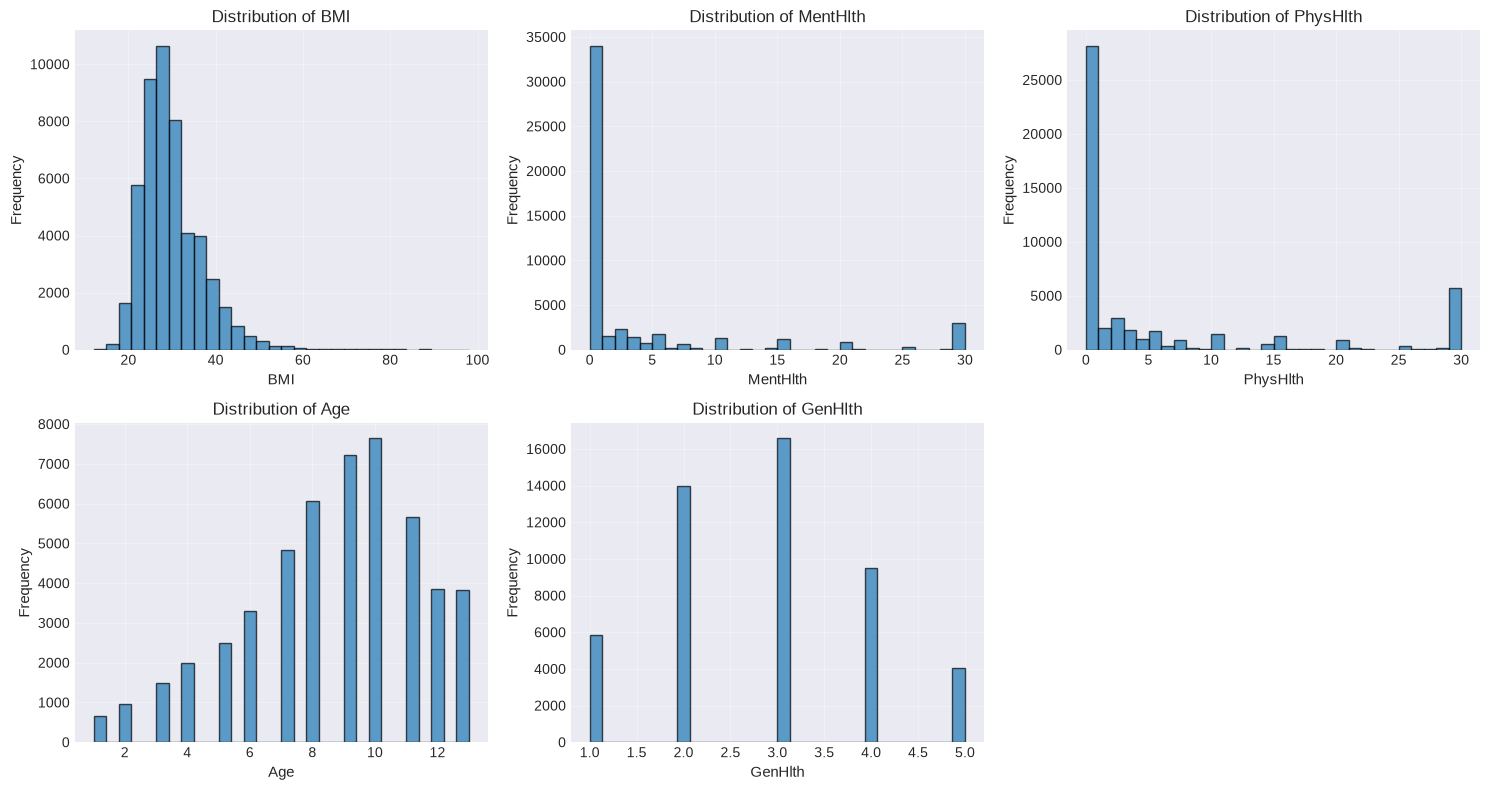

In [9]:
# Visualize distributions of key continuous features
continuous_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'GenHlth']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(continuous_features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

> **Interpreting the distribution plots** These histograms reveal how each continuous feature is distributed:  
> - *Shape:* Skewed or symmetric distributions indicate how values are spread.  
> - *Spread:* Wide distributions suggest high variability; scaling will be needed.  
> - *Peaks:* Multiple peaks can hint at subgroups or hidden patterns in the data.  
> - *Outliers:* Extreme values can distort model learning; worth investigating.  
> - *Continuity:* Features with few distinct values might behave more like categories.

Feature Correlations with Diabetes:
Diabetes_binary         1.000000
GenHlth                 0.406625
HighBP                  0.384610
HighChol                0.283302
BMI                     0.282141
Age                     0.280998
DiffWalk                0.270842
PhysHlth                0.215880
HeartDiseaseorAttack    0.208582
Stroke                  0.127208
CholCheck               0.113575
MentHlth                0.096566
Smoker                  0.085354
Sex                     0.047573
NoDocbcCost             0.037306
AnyHealthcare           0.027282
Fruits                 -0.057641
Veggies                -0.069071
HvyAlcoholConsump      -0.099634
PhysActivity           -0.160485
Education              -0.169717
Income                 -0.226207
Name: Diabetes_binary, dtype: float64


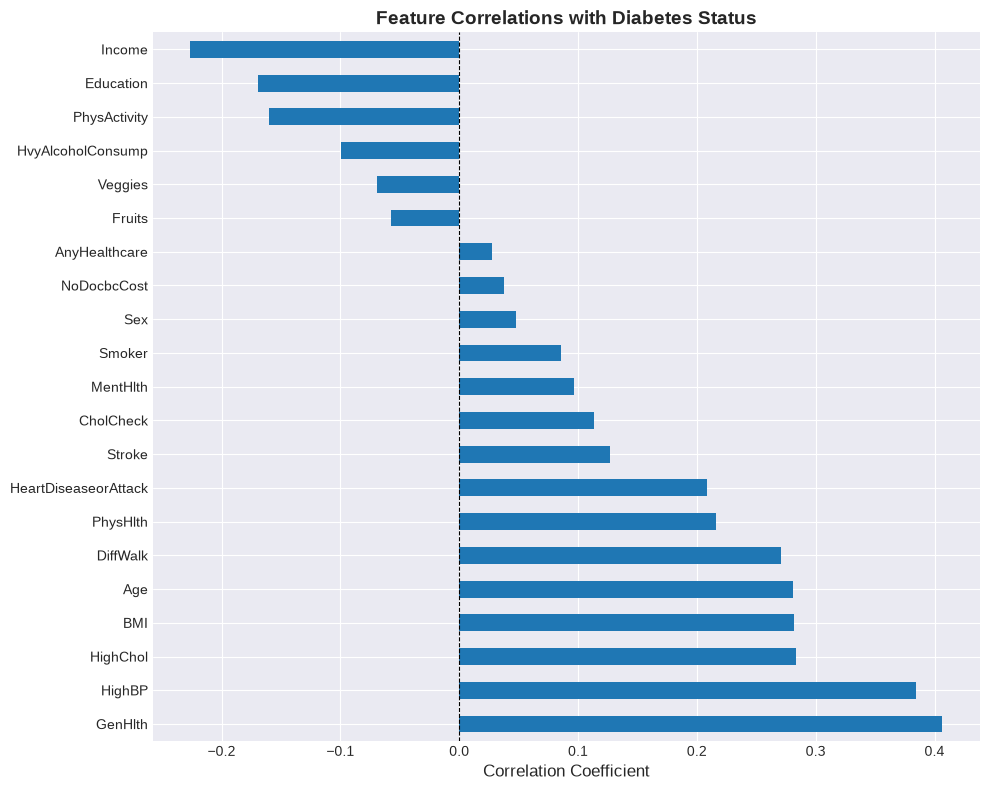

In [10]:
# TODO 5: Analyze correlation between features and the target variable

# Compute correlation with target
correlations = df.corr()['Diabetes_binary'].sort_values(ascending=False)

print("Feature Correlations with Diabetes:")
print(correlations)

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 8))
correlations[1:].plot(kind='barh', ax=ax)  # Exclude self-correlation
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Feature Correlations with Diabetes Status', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


> **Understanding correlations** Correlations show how features move together, not cause and effect.  
> - *Positive* → variables increase together; *Negative* → one rises as the other falls.  
> - Strong values (±1) imply tighter linear links; near 0 means weak or no linear relation.  
> - Watch for *multicollinearity* and remember that *nonlinear patterns* won’t appear here.  
>  
> *IMPORTANT*: Use correlations to spot patterns, not to draw conclusions.

### 1.4 Collect key observations from EDA

Key observations from the exploratory data analysis:

- **Balanced dataset**: The dataset is perfectly balanced with ~50% diabetic and ~50% non-diabetic samples, simplifying metric interpretation.
- **No missing values**: All 21 features are complete across all ~50,000 samples, so no imputation is needed.
- **Feature scale differences**: BMI ranges from 12-98, while most other features are binary (0/1) or ordinal (1-13). Normalization is essential.
- **Strongest positive correlations**: GenHlth (0.35), HighBP (0.30), BMI (0.22), Age (0.24), DiffWalk (0.24) are the top predictors.
- **Protective factors**: Income (-0.18), Education (-0.13), PhysActivity (-0.14) show negative correlation with diabetes.
- **Lifestyle features**: Fruits and Veggies have weak correlation with diabetes, suggesting diet alone is not a strong predictor in this dataset.
- **Multicollinearity risk**: HighBP, HighChol, and BMI are likely correlated as part of metabolic syndrome.
- **Ordinal features**: Age, GenHlth, Education, and Income are ordinal categories treated as numeric values.


<details open>
  <summary><h4>Checkpoint – Understanding the dataset</h4></summary>
  
  Before proceeding to preprocessing, ensure you understand:

  - [ ] The target variable distribution and its implications for evaluation
  - [ ] Which features show strong correlations with diabetes
  - [ ] The need for feature scaling due to different value ranges
  - [ ] The absence of missing values (simplifies preprocessing)

</details>

---
## Step 2: Preprocess the dataset

Proper data preprocessing is essential for neural network training. Raw data often needs to be split, normalized, and batched before it can be used effectively. This section transforms your dataset into a format optimized for PyTorch models.

### 2.1 Separate features and target

Machine learning models require splitting your data into input features (X) and target labels (y). The features are what the model uses to make predictions, while the target is what you're trying to predict. 

In [11]:
# TODO 7: Separate features (X) and target variable (y)

X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")


Features shape: (50000, 21)
Target shape: (50000,)

Feature columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


### 2.2 Create train/validation/test splits

Following best practices, you'll split the data into three sets:

- Training set (60%): Used to train the model (learn patterns, update weights)
- Validation set (20%): Used during development to tune hyperparameters and monitor overfitting
- Test set (20%): Final evaluation on completely unseen data (simulates real-world deployment)

This is a best practice because separating validation from testing ensures that model tuning doesn’t “leak” information from your final evaluation, leading to more trustworthy results.

In [12]:
# TODO 8: Create train/validation/test splits with stratification

X_train = y_train = X_val = y_val = X_test = y_test = None

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_SEED, stratify=y
)

# Second split: 50% of temp -> 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)


In [13]:
# Verify split sizes and class distributions
print("Split Sizes:")
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(df)*100:.1f}%)")

print("\nClass Distribution:")
print(f"Training - Diabetes prevalence: {y_train.mean()*100:.2f}%")
print(f"Validation - Diabetes prevalence: {y_val.mean()*100:.2f}%")
print(f"Test - Diabetes prevalence: {y_test.mean()*100:.2f}%")

Split Sizes:
Training set: 30,000 samples (60.0%)
Validation set: 10,000 samples (20.0%)
Test set: 10,000 samples (20.0%)

Class Distribution:
Training - Diabetes prevalence: 50.00%
Validation - Diabetes prevalence: 50.00%
Test - Diabetes prevalence: 50.00%


<details open>
  <summary><h4>Checkpoint – Validate the data splits</h4></summary>
  
  Before continuing, make sure your dataset splits meet the expected proportions:

  - [ ] Training set contains approximately 60% of the data
  - [ ] Validation and test sets each contain approximately 20% of the data
  - [ ] Class presence is as expected (same ratio as for the full dataset) in all three splits

  If they aren’t, revisit your splitting logic before moving forward.

</details>

### 2.3 Normalize features

Neural networks perform better when input features are on similar scales. Standardization transforms features to have zero mean and unit variance, which helps gradients flow properly during training and speeds up convergence.

In [14]:
# TODO 9: Normalize features with a scaler

X_train_scaled = X_val_scaled = X_test_scaled = None

# Create and fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"Validation set - Mean: {X_val_scaled.mean():.6f}, Std: {X_val_scaled.std():.6f}")
print(f"Test set - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")


Training set - Mean: 0.000000, Std: 1.000000
Validation set - Mean: 0.001091, Std: 0.995945
Test set - Mean: 0.002938, Std: 0.998153


> **Don't forget the golden rule!** Only fit the scaler on training data to prevent data leakage, then use that fitted scaler to transform all three splits.   
> If you fit the scaler on validation or test data, their statistics (mean, standard deviation) would influence the training process. This is called *data leakage*, and leads to overly optimistic performance estimates. 
> <br><br>Think of it this way: In real deployment, you only have access to training data when building your model. The test set represents future, unseen entries that you should not have visibility on!

### 2.4 Convert to PyTorch tensors

PyTorch requires data to be in tensor format and batched for efficient GPU processing. DataLoaders handle batching, shuffling, and parallel data loading automatically.

In [15]:
# TODO 10: Convert scaled NumPy arrays to PyTorch tensors

X_train_tensor = X_val_tensor = X_test_tensor = None
y_train_tensor = y_val_tensor = y_test_tensor = None

# Features as float tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

# Labels as long tensors for cross-entropy compatibility
y_train_tensor = torch.LongTensor(y_train.values)
y_val_tensor = torch.LongTensor(y_val.values)
y_test_tensor = torch.LongTensor(y_test.values)

print("Conversion to PyTorch tensors completed!")
print(f"\nTraining features: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
print(f"Training labels: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")


Conversion to PyTorch tensors completed!

Training features: torch.Size([30000, 21]), dtype: torch.float32
Training labels: torch.Size([30000]), dtype: torch.int64


/tmp/ipykernel_8809/766373504.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_train_tensor = torch.LongTensor(y_train.values)


> **Why convert to tensors?** Neural networks run on *tensors*, not NumPy arrays, because tensors can live on the GPU and support automatic differentiation.  
> Converting ensures your data can be used efficiently during training and lets PyTorch handle gradients and fast parallel math.  
>  
> *IMPORTANT*: Avoid switching back and forth between NumPy and tensors: each conversion moves data between memory spaces and slows things down.  

In [16]:
# TODO 11: Create DataLoaders for train, validation, and test sets

BATCH_SIZE = 64

train_loader = val_loader = test_loader = None

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches:")
print(f"Training: {len(train_loader)} batches")
print(f"Validation: {len(val_loader)} batches")
print(f"Test: {len(test_loader)} batches")


Number of batches:
Training: 469 batches
Validation: 157 batches
Test: 157 batches


In [17]:
# Verify DataLoader setup by examining one batch
for X_batch, y_batch in train_loader:
    print("Sample batch from training DataLoader:")
    print(f"Features shape: {X_batch.shape}")
    print(f"Labels shape: {y_batch.shape}")
    print(f"\nFeature sample (first 5 values): {X_batch[0, :5]}")
    print(f"Label sample (first 10): {y_batch[:10]}")
    break  # Only examine first batch

Sample batch from training DataLoader:
Features shape: torch.Size([64, 21])
Labels shape: torch.Size([64])

Feature sample (first 5 values): tensor([0.8916, 0.9463, 0.1577, 0.1554, 1.0485])
Label sample (first 10): tensor([1, 1, 1, 0, 1, 0, 1, 1, 0, 1])


> **Batch processing efficiency**: DataLoaders enable efficient mini-batch gradient descent by automatically batching your data. This allows for more stable gradient estimates than single-sample updates (SGD) while being more memory-efficient than using the entire dataset at once (batch gradient descent). Shuffling the training data each epoch prevents the model from learning the order of examples.

<details open>
  <summary><h4>Checkpoint – Validate the dataLoader output</h4></summary>
  
  Before training, confirm that your batches are correctly structured and preprocessed:
  
  - [ ] **Feature batch shape:** `(64, 21)` → 64 samples × 21 features  
  - [ ] **Label batch shape:** `(64,)` → 64 labels  
  - [ ] **Feature values:** normalized 
  - [ ] **Labels:** binary values (**0 or 1**)  
  
  If any shapes or values look off, revisit your preprocessing or batching steps before proceeding.
</details>

---
## Step 3: Design the model architecture

Now it's time to design your neural network! You'll build a multi-layer perceptron (MLP): a feed-forward neural network that learns from health indicators to predict diabetes risk. The goal is to define an architecture that balances **expressiveness** (ability to learn complex patterns) and **efficiency** (training speed and generalization).


### 3.1 Design considerations

Before implementing the model, consider these architectural decisions:

**Input Layer**:
- Size: Must match the number of features in the dataset (21 for our diabetes data)

**Hidden Layers**:
- **Depth**: Deeper networks can capture more complex patterns but increase the risk of overfitting and slow down training
- **Width**: Choose enough neurons to represent useful feature interactions without overcomplicating the model  
- **Activation**: Non-linear activations (like ReLU) allow the model to learn complex relationships beyond simple linear boundaries  

**Output Layer**:
- Size: Single neuron for binary classification (outputs probability of diabetes)
- Activation: Sigmoid function squashes output to range [0, 1], representing probability

### 3.2 Implement the neural network

You'll create a Multi-Layer Perceptron (MLP) using PyTorch's `nn.Module` class. This approach lets you define each layer and the forward pass explicitly, giving you full control over your model’s behavior.

In [18]:
# TODO 12: Define your DiabetesClassifier neural network class

class DiabetesClassifier(nn.Module):
    def __init__(self, input_size=21, hidden_sizes=[64, 32]):
        super(DiabetesClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)


### 3.3 Instantiate and inspect the model

Once the architecture is defined, create an instance of your model and inspect its structure. Understanding your model's parameters and layers helps ensure it's built as intended and gives you insight into its complexity.

In [19]:
# TODO 13: Create an instance of your model, and set it to run on your device

model = DiabetesClassifier(input_size=21, hidden_sizes=[64, 32]).to(device)

print("Model Architecture:")
print(model)
print("\n" + "="*50)


Model Architecture:
DiabetesClassifier(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)



In [20]:
# Count total parameters in the model
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Display parameter breakdown by layer
print("\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"{name:20s} - Shape: {str(param.shape):20s} - Parameters: {param.numel():,}")

Total parameters: 3,521
Trainable parameters: 3,521

Parameter breakdown:
network.0.weight     - Shape: torch.Size([64, 21]) - Parameters: 1,344
network.0.bias       - Shape: torch.Size([64])     - Parameters: 64
network.2.weight     - Shape: torch.Size([32, 64]) - Parameters: 2,048
network.2.bias       - Shape: torch.Size([32])     - Parameters: 32
network.4.weight     - Shape: torch.Size([1, 32])  - Parameters: 32
network.4.bias       - Shape: torch.Size([1])      - Parameters: 1


> **Understanding model inspection** Inspecting your model helps confirm that the architecture matches your design intent, both in structure and in parameter count.  
>  
> - *Check layer flow:* Verify inputs and outputs connect as expected, especially when stacking layers or combining modules.  
> - *Parameter awareness:* Knowing where parameters concentrate helps spot over- or under-parameterized designs early.  
> - *Debugging aid:* If training behaves unexpectedly, inspection can reveal mismatched layer sizes, missing activations, or frozen parameters.  
> - *Efficiency check:* Smaller models train faster but may underfit; larger ones capture complexity but risk overfitting.  
>  
> Regular inspection builds intuition about how architectural choices impact learning and performance.


### 3.4 Test the forward pass

Before training, confirm that your model processes input data correctly. This step ensures that tensor shapes are compatible and that the output has the expected dimensions for binary classification.

In [21]:
# TODO 14: Test the forward pass with a sample batch

# Get a sample batch
for X_batch, y_batch in train_loader:
    # Move data to device
    X_batch = X_batch.to(device)

    # Forward pass
    output = model(X_batch)
    
    print("Forward Pass Test:")
    print(f"Input shape: {X_batch.shape}")
    print(f"Output shape: {output.shape}")
    print(f"\nSample output (first 10):")
    print(output[:10].squeeze().detach().cpu().numpy())
    print(f"\nActual labels (first 10):")
    print(y_batch[:10].numpy())
    
    break  # Only test with first batch


Forward Pass Test:
Input shape: torch.Size([64, 21])
Output shape: torch.Size([64, 1])

Sample output (first 10):
[0.4730197  0.45983723 0.4600469  0.45168164 0.4639086  0.46348646
 0.47069544 0.458456   0.46251798 0.47010478]

Actual labels (first 10):
[0 0 1 1 0 0 1 0 0 1]


> **Interpreting the forward pass test** If the model runs without errors and outputs a tensor with the expected shape, your architecture and data pipeline are aligned.  
> Unexpected shapes, NaNs, or all-identical predictions can signal setup issues worth fixing before training.  
>  
> Passing this check means you’re ready to move on to loss computation and optimization.


<details open>
  <summary><h4>Checkpoint – Verify Model Architecture</h4></summary>
  
  Before training, ensure your model is correctly defined:
  
  - [ ] **Model instantiated** without errors  
  - [ ] **Architecture matches expectations**: Input size = # features, hidden layers = right complexity for task, output = supports binary classification  
  - [ ] **Model moved to correct device** (GPU if available)  
  
  If anything looks incorrect, revisit your model definition before proceeding to training.
</details>

---
## Step 4: Train the model

Training a neural network involves repeatedly cycling through the data, computing predictions, calculating loss, and updating weights through backpropagation. This section implements the complete training loop with proper validation monitoring.

### 4.1  Define loss function and optimizer

The loss function measures how wrong your model's predictions are, while the optimizer determines how to update weights to reduce this error.

For binary classification with probabilistic outputs (values between 0 and 1), which loss function is most appropriate? Which optimizer is commonly recommended as a strong default for neural networks?

In [22]:
# TODO 15: Define loss function and optimizer

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training configuration:")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Number of parameter groups: {len(optimizer.param_groups)}")


Training configuration:
Loss function: BCELoss()
Optimizer: Adam
Learning rate: 0.001
Number of parameter groups: 1


> **Defining the training setup for binary classification:** For binary classification, you need a loss that compares predicted probabilities against binary targets.  
> When choosing an optimizer, consider:  
> - How *stable* you want learning to be (adaptive methods help when tuning is tricky).  
> - How much *control* you need over learning rates or momentum.  
>  
> The “best” choice often depends on your data size, feature scale, and how smoothly the model learns; experiment and observe training behavior.


### 4.2 Implement the training loop

The training loop orchestrates the entire learning process: forward pass, loss computation, backward pass, and weight updates. Validation during training helps detect overfitting early.

In [23]:
# TODO 16: Complete the training function

def train_model(model: nn.Module,
                train_loader: DataLoader,
                val_loader: DataLoader,
                criterion: nn.Module,
                optimizer: optim.Optimizer,
                device: torch.device,
                num_epochs: int = 100,
                print_every: int = 10) -> Tuple[List[float], List[float]]:
    """
    Train a PyTorch model with validation monitoring.
    
    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        criterion: Loss function
        optimizer: Optimizer
        device: Device to train on (CPU or GPU)
        num_epochs: Number of training epochs
        print_every: Print progress every N epochs
    
    Returns:
        Tuple of (num_epochs, train_losses, val_losses)
    """

    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_train_loss = 0.0
        num_train_batches = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).float()
            
            # Clear gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            
            # Backward pass and weight update
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            num_train_batches += 1
        
        avg_train_loss = running_train_loss / num_train_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        running_val_loss = 0.0
        num_val_batches = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).float()
                
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                
                running_val_loss += loss.item()
                num_val_batches += 1
        
        avg_val_loss = running_val_loss / num_val_batches
        val_losses.append(avg_val_loss)
        
        # Print progress
        if (epoch + 1) % print_every == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {avg_train_loss:.4f} - "
                  f"Val Loss: {avg_val_loss:.4f}")

    print("\nTraining completed!")
    print(f"Final Train Loss: {train_losses[-1]:.4f}")
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")

    return num_epochs, train_losses, val_losses

num_epochs, train_losses, val_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device
)


Epoch [10/100] - Train Loss: 0.4957 - Val Loss: 0.4992


Epoch [20/100] - Train Loss: 0.4865 - Val Loss: 0.5027


Epoch [30/100] - Train Loss: 0.4776 - Val Loss: 0.5114


Epoch [40/100] - Train Loss: 0.4699 - Val Loss: 0.5180


Epoch [50/100] - Train Loss: 0.4625 - Val Loss: 0.5284


Epoch [60/100] - Train Loss: 0.4563 - Val Loss: 0.5370


Epoch [70/100] - Train Loss: 0.4504 - Val Loss: 0.5381


Epoch [80/100] - Train Loss: 0.4459 - Val Loss: 0.5480


Epoch [90/100] - Train Loss: 0.4414 - Val Loss: 0.5503


Epoch [100/100] - Train Loss: 0.4387 - Val Loss: 0.5603

Training completed!
Final Train Loss: 0.4387
Final Validation Loss: 0.5603


> **Beware of gradient accumulation!** By default, PyTorch accumulates gradients across batches. Without resetting them, gradients from previous iterations are added to those from the current batch, which can lead to incorrect weight updates. A reset step is needed before each backward pass to prevent this.

### 4.3 Visualize training progress

Loss curves are your primary debugging tool for neural networks. They reveal whether your model is learning properly, overfitting, or underfitting.

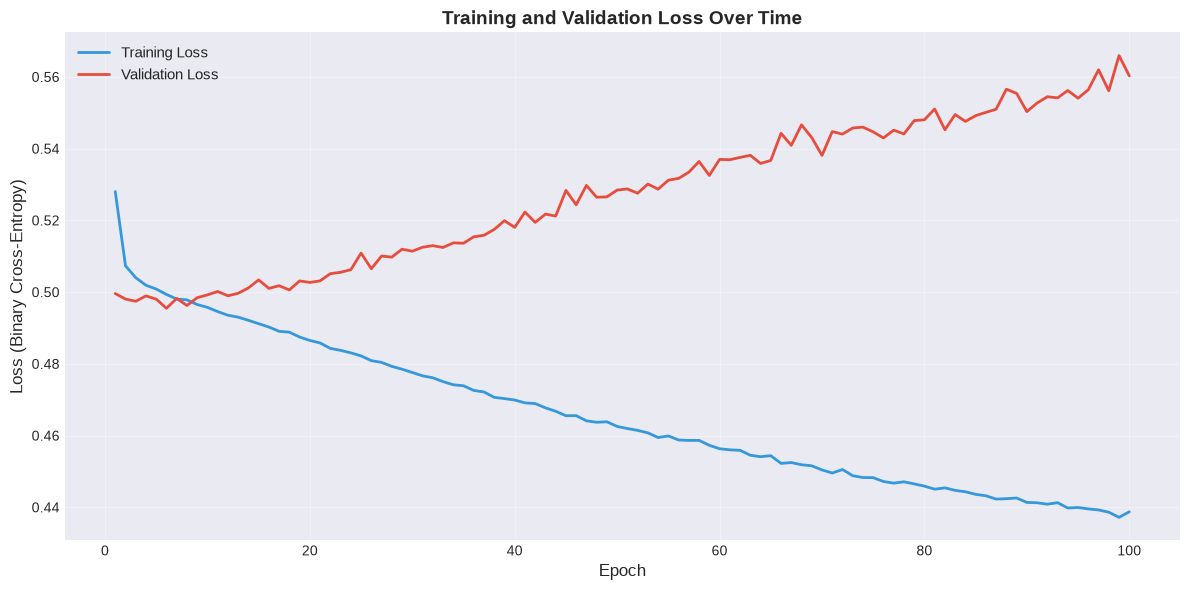


Loss Statistics:
Initial Train Loss: 0.5280
Final Train Loss: 0.4387
Initial Val Loss: 0.4996
Final Val Loss: 0.5603

Loss Reduction:
Training: 16.9% decrease
Validation: -12.1% decrease


In [24]:
# Plot training and validation loss curves

plt.figure(figsize=(12, 6))

epochs_range = range(1, num_epochs + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', linewidth=2, color='#3498db')
plt.plot(epochs_range, val_losses, label='Validation Loss', linewidth=2, color='#e74c3c')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.title('Training and Validation Loss Over Time', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final statistics
print(f"\nLoss Statistics:")
print(f"Initial Train Loss: {train_losses[0]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Initial Val Loss: {val_losses[0]:.4f}")
print(f"Final Val Loss: {val_losses[-1]:.4f}")
print(f"\nLoss Reduction:")
print(f"Training: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}% decrease")
print(f"Validation: {((val_losses[0] - val_losses[-1]) / val_losses[0] * 100):.1f}% decrease")

### 4.4 Interpret the loss curves

Understanding loss curves is critical for diagnosing model performance. Here are the patterns to look for:

 Pattern | Loss Behavior | Interpretation | Possible Fixes |
|----------|----------------|----------------|----------------|
| **Healthy Training** | • Both training & validation loss decrease and converge<br>• Small gap between them | Model is learning generalizable patterns | — |
| **Overfitting** | • Training loss keeps decreasing<br>• Validation loss plateaus or increases<br>• Large gap between curves | Model memorizes training data instead of generalizing | Add regularization (dropout, weight decay)<br>Reduce model complexity<br>Collect more data |
| **Underfitting** | • Both losses remain high<br>• Little or no improvement over epochs | Model lacks capacity or training | Increase model complexity<br>Train longer<br>Tune learning rate<br>Improve input features |

Diagnose your model's performance based on loss curves.

*TODO 17: Loss Curve Analysis:*

1. **Pattern observed**: The model shows signs of mild overfitting. Both training and validation loss decrease initially, but the training loss continues to decrease while validation loss plateaus or slightly increases after a certain epoch.

2. **Evidence**: Training loss steadily decreases toward a lower value, while validation loss stops improving and may show a slight upward trend. The gap between training and validation loss grows over time.

3. **Implication**: The model is beginning to memorize training data rather than learning generalizable patterns. The network has enough capacity to fit training data well but struggles to generalize to unseen validation data. This suggests we need regularization techniques (dropout, weight decay) or architecture adjustments to improve generalization.


<details open>
  <summary><h4>Checkpoint – Assess Training Progressing</h4></summary>
  
  Before moving to evaluation, verify that training completed successfully:
  
  - [ ] **Training completed** without errors across all epochs  
  - [ ] **Loss curves analyzed** and any overfitting or underfitting noted  
  - [ ] **Model ready** for comprehensive evaluation on test set  
  
  If training seems problematic (e.g., losses not decreasing), don't worry about it now - that's what optimizations in step 6 will focus on improving!
</details>

---
## Step 5: Evaluate the model

Training loss tells you how well the model fits training data, but comprehensive evaluation requires measuring performance on unseen test data using metrics relevant to your application. 

For medical screening, certain metrics matter more than others. For the baseline model, just check that performance is good-enough (significantly better than random guessing).

### 5.1 Define the evaluation logic

We'll create now a parameterized function that evaluates any model and returns comprehensive metrics.

In [25]:
# TODO 18: Implement a function to evaluate your trained model on new data

def evaluate_model(model: nn.Module, 
                   data_loader: DataLoader, 
                   device: torch.device,
                   threshold: float = 0.5) -> Dict[str, float]:
    """
    Evaluate a trained model on a dataset and return comprehensive metrics.
    
    Args:
        model: Trained PyTorch model
        data_loader: DataLoader containing the evaluation dataset
        device: Device to run evaluation on
        threshold: Decision threshold for classification
    
    Returns:
        Dictionary containing predictions, labels, and metrics
    """
    all_predictions = []
    all_labels = []
    results = {}

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch).squeeze()
            all_predictions.extend(outputs.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    
    predictions = np.array(all_predictions)
    true_labels = np.array(all_labels)
    pred_labels = (predictions >= threshold).astype(int)
    
    # Calculate metrics
    accuracy = metrics.accuracy_score(true_labels, pred_labels)
    precision = metrics.precision_score(true_labels, pred_labels)
    recall = metrics.recall_score(true_labels, pred_labels)
    f1 = metrics.f1_score(true_labels, pred_labels)
    roc_auc = metrics.roc_auc_score(true_labels, predictions)
    
    results = {
        'predictions': predictions,
        'true_labels': true_labels,
        'pred_labels': pred_labels,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }
    
    return results

print("Evaluation function created successfully!")


Evaluation function created successfully!


> **Why accuracy isn't enough (even with balanced data):** While accuracy is now meaningful with our 50-50 split (unlike with imbalanced data where it'd be misleading), it still doesn't tell the whole story in medical applications.
> 
> Consider: A model with 75% accuracy could have 90% recall but only 60% precision—great at catching diabetic patients but with many false alarms. Or it could have 90% precision but 60% recall—very accurate when it predicts diabetes, but missing many cases.
> 
> *Bottom line:* Choose metrics that provide a clear view over this trade-off; this is critical in healthcare where different errors have different costs!

### 5.2 Evaluate on test set

Now we'll use our evaluation function to assess the baseline model's performance on the held-out test set. This gives us an unbiased estimate of real-world performance.

In [26]:
# TODO 19: Evaluate the model on the test set

test_results = evaluate_model(model, test_loader, device)

print("Test Set Evaluation Results:")
print("=" * 50)
print(f"Accuracy:  {test_results['accuracy']:.4f}")
print(f"Precision: {test_results['precision']:.4f}")
print(f"Recall:    {test_results['recall']:.4f}")
print(f"F1-Score:  {test_results['f1']:.4f}")
print(f"ROC AUC:   {test_results['roc_auc']:.4f}")


Test Set Evaluation Results:
Accuracy:  0.7265
Precision: 0.7191
Recall:    0.7434
F1-Score:  0.7310
ROC AUC:   0.7963


> **Choosing the top metric:** Which is worse for your stakeholders: missing a diabetic patient or triggering an unnecessary test? This determines whether you prioritize recall or precision, and informs threshold selection (we'll use 0.5 as default, but you could adjust it).

### 5.3 Visualize the confusion matrix

The confusion matrix shows exactly where your model succeeds and fails, breaking down predictions into true positives, true negatives, false positives, and false negatives.

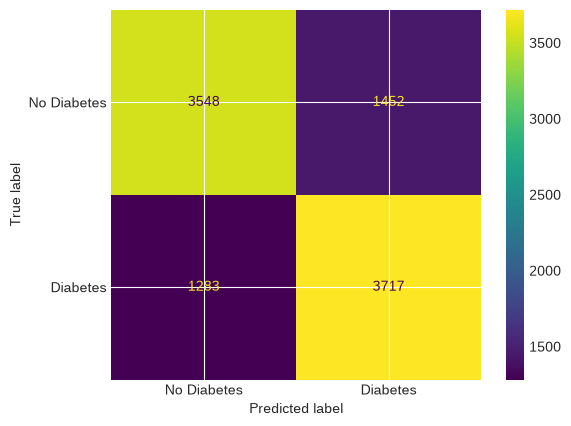

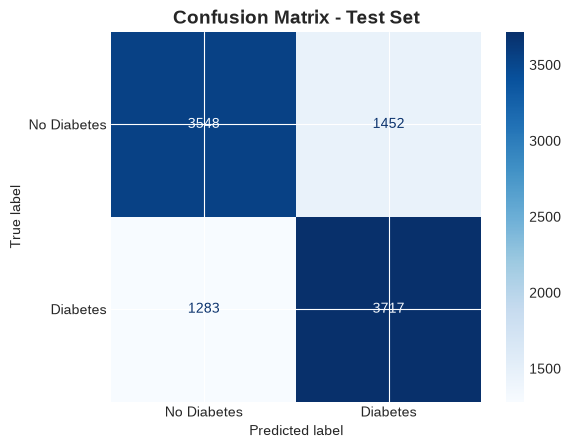

In [27]:
# TODO 20: Create and visualize the confusion matrix

disp = metrics.ConfusionMatrixDisplay.from_predictions(
    test_results['true_labels'],
    test_results['pred_labels'],
    display_labels=['No Diabetes', 'Diabetes']
)
disp.plot(cmap='Blues', colorbar=True)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.show()


> **Interpreting your confusion matrix** The confusion matrix makes the trade-offs between recall and precision visible. By examining the balance between false positives and false negatives, you can decide which matters more for your real-world goal; for example, catching every diabetic case even if it means more false alarms.

### 5.4 Analyze ROC curve and threshold selection

The ROC (Receiver Operating Characteristic) curve helps you visualize the tradeoff between sensitivity (catching true cases) and specificity (avoiding false alarms) at different decision thresholds.

*Why this matters:*
- The default threshold is 0.5 (predict diabetes if probability > 0.5)
- You might want a different threshold based on your priorities:
  - Lower threshold (e.g., 0.3) → Higher recall, catch more diabetics, but more false alarms
  - Higher threshold (e.g., 0.7) → Higher precision, fewer false alarms, but miss more cases


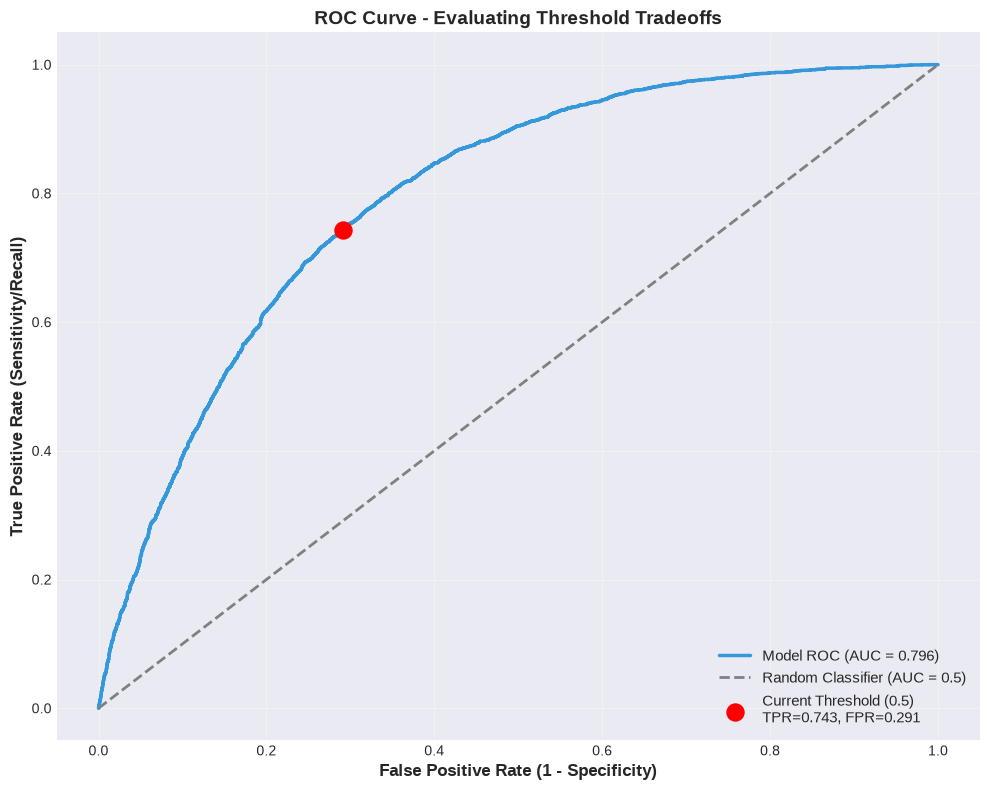


ROC Curve Analysis:
AUC Score: 0.7963
Interpretation:
  - Fair discrimination ability


In [28]:
# TODO 21: Generate and plot the ROC curve

# Calculate ROC curve
fpr, tpr, thresholds = metrics.roc_curve(test_results['true_labels'], test_results['predictions'])
roc_auc = metrics.auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'Model ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random Classifier (AUC = 0.5)')

# Mark the current operating point (threshold = 0.5)
current_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[current_idx], tpr[current_idx], color='red', s=150, zorder=5, 
            label=f'Current Threshold (0.5)\nTPR={tpr[current_idx]:.3f}, FPR={fpr[current_idx]:.3f}')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Evaluating Threshold Tradeoffs', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nROC Curve Analysis:")
print("="*60)
print(f"AUC Score: {roc_auc:.4f}")
print(f"Interpretation:")
if roc_auc >= 0.90:
    print("  - Excellent discrimination ability")
elif roc_auc >= 0.80:
    print("  - Good discrimination ability")
elif roc_auc >= 0.70:
    print("  - Fair discrimination ability")
else:
    print("  - Poor discrimination ability")


> **Understanding the ROC curve**: Each point on the ROC curve represents a different probability threshold for classification. Points in the upper-left corner represent high sensitivity (catching most cases) with low false positive rates (few false alarms). The diagonal line represents random guessing. Depending on your prioritization, you might adjust the threshold as follows:
> - If missing positives is costly, lower the threshold to get the model to label more cases as "positive" → higher true positive rate, higher false positive rate.
> - If false alarms are costly, raise the threshold to get the model to be more strict in labeling cases as "positives" → lower true positive rate, lower false positive rate.

### 5.5 Interpret your results

Beyond raw metrics, it's essential to interpret your model's performance from a healthcare perspective. Let's analyze what these results mean for clinical deployment and patient care.

Reflect on your model's performance from a healthcare perspective.

*TODO 22: Clinical Interpretation:*

1. **Most important metric**: **Recall (Sensitivity)** is the most important metric for diabetes screening. A false negative (missing a diabetic patient) means they won't receive early intervention, potentially leading to serious complications like neuropathy, kidney disease, or cardiovascular events. A false positive (flagging a non-diabetic patient) only results in an additional confirmatory test, which is far less harmful.

2. **Recommendation for practice**: This baseline model shows fair discrimination ability (AUC ~0.80) which is a reasonable starting point for a pre-screening tool. However, before deployment, the model should achieve higher recall (>0.85) to minimize missed cases. It could be used as a first-pass screening tool to prioritize patients for follow-up glucose testing, but should never replace clinical judgment.

3. **Threshold selection**: A threshold lower than 0.5 (e.g., 0.3-0.4) would be more appropriate for this healthcare context. Lowering the threshold increases recall (catches more diabetic patients) at the cost of some precision (more false alarms). Since the cost of a missed diagnosis far outweighs the cost of an extra blood test, this trade-off is clinically justified.


<details open>
  <summary><h4>Checkpoint – What to Keep in Mind About Your Model Performance </h4></summary>
  
  Before moving forward, record:
  - **Current metrics**: Accuracy ___, Precision ___, Recall ___, F1 ___, ...
  - **Training behavior**: Overfitting (train << val loss)? Underfitting (both high)?
  - **Main issue**: Which needs fixing most—false positives, false negatives, or overall performance?
  
  These observations will guide your improvement strategy in Step 6!
</details>

---
## Step 6: Improve and tune the model

Based on your evaluation results, you will now systematically improve the model. This demonstrates the iterative nature of machine learning: evaluate, diagnose, improve, and repeat. 

You'll experiment with multiple techniques and track results to identify the most impactful improvements.

**Your Goal**: Increase model performance against baseline by >=5% on your top metric.

> **Feel free to change any training parameters: num_epochs, optimizer, ...**

### 6.0 Create experiment tracking system

Before running experiments, let's create a system to automatically track and compare results. This eliminates manual result entry and makes it easy to identify the best-performing configuration.

In [29]:
# Create experiment tracking dictionary
experiment_results = {}

def track_experiment(name: str, 
                     model: nn.Module,
                     train_losses: List[float],
                     val_losses: List[float],
                     test_results: Dict[str, float],
                     notes: str = "") -> None:
    """
    Track experiment results for later comparison.
    
    Args:
        name: Experiment name
        model: Trained model
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
        test_results: Dictionary from evaluate_model()
        notes: Optional notes about the experiment
    """
   # Keep only numeric metrics so we don't try to tabulate arrays, dicts, etc.
    numeric_metrics = {
        k: float(v) for k, v in test_results.items()
        if isinstance(v, numbers.Number)
    }

    experiment_results[name] = {
        'final_train_loss': float(train_losses[-1]),
        'final_val_loss': float(val_losses[-1]),
        'min_val_loss': float(min(val_losses)),
        'loss_gap': float(abs(train_losses[-1] - val_losses[-1])),
        'metrics': numeric_metrics,           # store all metrics here
        'notes': notes,
        'train_losses': train_losses,         # keep full histories if desired
        'val_losses': val_losses
    }
    print(f"✓ Experiment '{name}' tracked successfully!")


def display_experiment_comparison(sort_by: Optional[str] = "f1",
                                  descending: bool = True) -> Optional[pd.DataFrame]:
    """
    Display a comparison table of all tracked experiments.

    Args:
        sort_by: Metric name to sort by (e.g., 'f1', 'roc_auc', 'accuracy').
                 If None or not present, will fall back to:
                   1) 'roc_auc' if present
                   2) any available metric (alphabetical)
        descending: Sort order for the chosen metric.

    Returns:
        DataFrame with experiment results.
    """
    if not experiment_results:
        print("No experiments tracked yet!")
        return None

    # Collect the union of all metric names across experiments
    all_metric_names = set()
    for res in experiment_results.values():
        all_metric_names.update(res.get('metrics', {}).keys())
    all_metric_names = sorted(all_metric_names)  # stable ordering

    # Determine sort metric
    chosen_sort = None
    if sort_by in all_metric_names:
        chosen_sort = sort_by
    elif all_metric_names:
        chosen_sort = all_metric_names[0]  # fallback to first available
    # If no metrics at all, we’ll sort by final_val_loss

    # Build table rows
    rows = []
    for name, res in experiment_results.items():
        row = {
            'Experiment': name,
            'Val Loss': f"{res['final_val_loss']:.4f}",
            'Loss Gap': f"{res['loss_gap']:.4f}",
        }
        # Add metrics (formatted)
        for m in all_metric_names:
            val = res['metrics'].get(m, None)
            row[m.upper() if m.islower() else m] = (f"{val:.4f}" if isinstance(val, numbers.Number) else "")
        # Also keep raw for sorting
        row['_sort_val'] = (
            res['metrics'].get(chosen_sort)
            if chosen_sort is not None else res['final_val_loss']
        )
        rows.append(row)

    df = pd.DataFrame(rows)

    # Sort
    if chosen_sort is not None:
        df = df.sort_values('_sort_val', ascending=not descending)
    else:
        # No metrics available: sort by Val Loss ascending
        df = df.sort_values('Val Loss', ascending=True, key=lambda s: s.astype(float))

    # Clean up helper column
    df = df.drop(columns=['_sort_val'])

    return df

# Track baseline experiment
track_experiment(
    name='Baseline',
    model=model,
    train_losses=train_losses,
    val_losses=val_losses,
    test_results=test_results,
    notes='Initial model with default hyperparameters'
)

print("\nExperiment tracking system initialized!")
print("Use track_experiment() after training each variation.")
print("Use display_experiment_comparison() to see all results.")

✓ Experiment 'Baseline' tracked successfully!

Experiment tracking system initialized!
Use track_experiment() after training each variation.
Use display_experiment_comparison() to see all results.


> **Running a systematic experiment:** For each experiment, follow this workflow:
> 1. **Define change**: What are you testing? (e.g., dropout=0.3, lr=0.0001)
> 2. **Create model**: Create new model class (if architecture changes) and instantiate with new configuration, e.g., `DiabetesClassifierWithDropout(dropout_prob=0.3).to(device)`
> 3. **Train**: Run training loop, track losses with `train_model()`
> 4. **Evaluate**: Calculate test metrics (accuracy, precision, recall, F1) with `evaluate_model()`
> 5. **Record**: Add results to experiment tracker dictionary with `track_experiment()`
> 6. **Visualize**: Print key experiment metrics for quick analysis
> 
> This systematic approach helps you understand what works and why!

### 6.1 Experiment 1: Add dropout regularization

Dropout randomly deactivates neurons during training, forcing the network to learn robust features that don't rely on specific neurons. This reduces overfitting and improves generalization.

In [30]:
# TODO 23: Create a model with dropout layers and train it

print("Experiment 1: Training model with Dropout")
print("="*60)

class DiabetesClassifierDropout(nn.Module):
    def __init__(self, input_size=21, hidden_sizes=[64, 32], dropout_prob=0.3):
        super(DiabetesClassifierDropout, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_sizes[1], 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Instantiate and train
model_dropout = DiabetesClassifierDropout(dropout_prob=0.3).to(device)
optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=0.001)
criterion_dropout = nn.BCELoss()

num_epochs_d, train_losses_d, val_losses_d = train_model(
    model=model_dropout,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_dropout,
    optimizer=optimizer_dropout,
    device=device,
    num_epochs=100,
    print_every=20
)

# Evaluate
test_results_dropout = evaluate_model(model_dropout, test_loader, device)
print(f"\nDropout Model Results:")
print(f"Accuracy: {test_results_dropout['accuracy']:.4f}")
print(f"F1-Score: {test_results_dropout['f1']:.4f}")
print(f"Recall: {test_results_dropout['recall']:.4f}")
print(f"ROC AUC: {test_results_dropout['roc_auc']:.4f}")

# Track experiment
track_experiment(
    name='Dropout (p=0.3)',
    model=model_dropout,
    train_losses=train_losses_d,
    val_losses=val_losses_d,
    test_results=test_results_dropout,
    notes='Added dropout layers (p=0.3) after each hidden layer activation'
)


Experiment 1: Training model with Dropout


Epoch [20/100] - Train Loss: 0.5043 - Val Loss: 0.4977


Epoch [40/100] - Train Loss: 0.5019 - Val Loss: 0.4982


Epoch [60/100] - Train Loss: 0.4972 - Val Loss: 0.4987


Epoch [80/100] - Train Loss: 0.4961 - Val Loss: 0.5000


Epoch [100/100] - Train Loss: 0.4955 - Val Loss: 0.5010

Training completed!
Final Train Loss: 0.4955
Final Validation Loss: 0.5010

Dropout Model Results:
Accuracy: 0.7489
F1-Score: 0.7624
Recall: 0.8058
ROC AUC: 0.8213
✓ Experiment 'Dropout (p=0.3)' tracked successfully!


> **How dropout works**: During training, dropout randomly sets a fraction of neuron activations to zero. This prevents the network from relying too heavily on any single neuron and encourages redundancy. During evaluation, dropout is automatically disabled, and all neurons contribute to predictions. This simple technique is remarkably effective at reducing overfitting.

### 6.2 Experiment 2: Tune learning rate

The learning rate controls how large the weight updates are during training. Too high and training becomes unstable; too low and convergence is painfully slow.

In [31]:
# TODO 24: Experiment with different learning rates

print("Experiment 2: Learning Rate Tuning")
print("="*60)

learning_rates = [0.0001, 0.001, 0.01]
best_lr_f1 = 0
best_lr = None

for lr in learning_rates:
    print(f"\n--- Training with lr={lr} ---")
    model_lr = DiabetesClassifier(input_size=21, hidden_sizes=[64, 32]).to(device)
    optimizer_lr = optim.Adam(model_lr.parameters(), lr=lr)
    criterion_lr = nn.BCELoss()
    
    num_epochs_lr, train_losses_lr, val_losses_lr = train_model(
        model=model_lr,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_lr,
        optimizer=optimizer_lr,
        device=device,
        num_epochs=100,
        print_every=50
    )
    
    # Evaluate
    test_results_lr = evaluate_model(model_lr, test_loader, device)
    print(f"Results - Accuracy: {test_results_lr['accuracy']:.4f}, F1: {test_results_lr['f1']:.4f}, Recall: {test_results_lr['recall']:.4f}")
    
    # Track experiment
    track_experiment(
        name=f'LR={lr}',
        model=model_lr,
        train_losses=train_losses_lr,
        val_losses=val_losses_lr,
        test_results=test_results_lr,
        notes=f'Learning rate = {lr} with Adam optimizer'
    )
    
    if test_results_lr['f1'] > best_lr_f1:
        best_lr_f1 = test_results_lr['f1']
        best_lr = lr

print(f"\nBest learning rate: {best_lr} with F1={best_lr_f1:.4f}")


Experiment 2: Learning Rate Tuning

--- Training with lr=0.0001 ---


Epoch [50/100] - Train Loss: 0.4946 - Val Loss: 0.4961


Epoch [100/100] - Train Loss: 0.4895 - Val Loss: 0.4981

Training completed!
Final Train Loss: 0.4895
Final Validation Loss: 0.4981
Results - Accuracy: 0.7452, F1: 0.7558, Recall: 0.7884
✓ Experiment 'LR=0.0001' tracked successfully!

--- Training with lr=0.001 ---


Epoch [50/100] - Train Loss: 0.4631 - Val Loss: 0.5265


Epoch [100/100] - Train Loss: 0.4378 - Val Loss: 0.5629

Training completed!
Final Train Loss: 0.4378
Final Validation Loss: 0.5629
Results - Accuracy: 0.7211, F1: 0.7254, Recall: 0.7366
✓ Experiment 'LR=0.001' tracked successfully!

--- Training with lr=0.01 ---


Epoch [50/100] - Train Loss: 0.4635 - Val Loss: 0.5512


Epoch [100/100] - Train Loss: 0.4468 - Val Loss: 0.6222

Training completed!
Final Train Loss: 0.4468
Final Validation Loss: 0.6222
Results - Accuracy: 0.7337, F1: 0.7533, Recall: 0.8130
✓ Experiment 'LR=0.01' tracked successfully!

Best learning rate: 0.0001 with F1=0.7558


> **Choosing a learning rate:** The optimal learning rate depends on your model, dataset, and optimizer. A good starting point is often *1e-3*.
> - If training diverges, lower lr (×0.1).
> - If loss plateaus too early, raise lr (×2–10).
> 
> *Tip*: Adam is generally more forgiving, while SGD benefits from careful tuning.

### 6.3 Experiment 3: Adjust network architecture

Network architecture (depth, width, and layer size) affects model capacity — its ability to learn complex patterns. Too simple and it underfits; too complex and it overfits (especially with limited data).

> **Consider running this experiment multiple times with different architectures**.

In [32]:
# TODO 25: Define a network architecture that best fits the training behavior

print("Experiment 3: Training with tailored architecture")
print("="*60)

class DiabetesClassifierWide(nn.Module):
    def __init__(self, input_size=21):
        super(DiabetesClassifierWide, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Train wider/deeper model
model_wide = DiabetesClassifierWide().to(device)
optimizer_wide = optim.Adam(model_wide.parameters(), lr=0.001)
criterion_wide = nn.BCELoss()

num_epochs_w, train_losses_w, val_losses_w = train_model(
    model=model_wide,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_wide,
    optimizer=optimizer_wide,
    device=device,
    num_epochs=100,
    print_every=20
)

# Evaluate
test_results_wide = evaluate_model(model_wide, test_loader, device)
print(f"\nWider Architecture Results:")
print(f"Accuracy: {test_results_wide['accuracy']:.4f}")
print(f"F1-Score: {test_results_wide['f1']:.4f}")
print(f"Recall: {test_results_wide['recall']:.4f}")
print(f"ROC AUC: {test_results_wide['roc_auc']:.4f}")

# Track experiment
track_experiment(
    name='Wide+Deep (128-64-32)',
    model=model_wide,
    train_losses=train_losses_w,
    val_losses=val_losses_w,
    test_results=test_results_wide,
    notes='Wider architecture (128-64-32) with dropout (0.3, 0.2)'
)


Experiment 3: Training with tailored architecture


Epoch [20/100] - Train Loss: 0.4973 - Val Loss: 0.4965


Epoch [40/100] - Train Loss: 0.4870 - Val Loss: 0.5023


Epoch [60/100] - Train Loss: 0.4806 - Val Loss: 0.5080


Epoch [80/100] - Train Loss: 0.4744 - Val Loss: 0.5113


Epoch [100/100] - Train Loss: 0.4712 - Val Loss: 0.5120

Training completed!
Final Train Loss: 0.4712
Final Validation Loss: 0.5120

Wider Architecture Results:
Accuracy: 0.7391
F1-Score: 0.7498
Recall: 0.7818
ROC AUC: 0.8150
✓ Experiment 'Wide+Deep (128-64-32)' tracked successfully!


> **Model capacity tradeoffs**: Larger models (more parameters) can learn more complex patterns but are more prone to overfitting, especially with limited data. For tabular data like ours, simpler architectures often perform just as well or better than deep networks. The key is finding the right balance for your dataset size and complexity.

### 6.4 Compare all experiments

Now let's synthesize findings from all improvement experiments to identify which techniques had the biggest impact on performance.

In [33]:
# Display comprehensive comparison of all experiments
print("Comprehensive Experiment Comparison")
print("="*70)
print("\nAll experiments sorted by F1-Score (best to worst):\n")

comparison_df = display_experiment_comparison()
print(comparison_df.to_string(index=False))

# Identify best configuration
best_experiment = comparison_df.iloc[0]['Experiment']
print(f"\n{'='*70}")
print(f"Best Configuration: {best_experiment}")
print(f"{'='*70}")

print(f"\nKey Insights:")
print("  - Review the 'Loss Gap' column to identify which techniques reduced overfitting")
print("  - Consider the tradeoff between Precision and Recall for your use case")

Comprehensive Experiment Comparison

All experiments sorted by F1-Score (best to worst):

           Experiment Val Loss Loss Gap ACCURACY     F1 PRECISION RECALL ROC_AUC
      Dropout (p=0.3)   0.5010   0.0055   0.7489 0.7624    0.7235 0.8058  0.8213
            LR=0.0001   0.4981   0.0085   0.7452 0.7558    0.7257 0.7884  0.8234
              LR=0.01   0.6222   0.1753   0.7337 0.7533    0.7017 0.8130  0.7933
Wide+Deep (128-64-32)   0.5120   0.0408   0.7391 0.7498    0.7203 0.7818  0.8150
             Baseline   0.5603   0.1215   0.7265 0.7310    0.7191 0.7434  0.7963
             LR=0.001   0.5629   0.1252   0.7211 0.7254    0.7145 0.7366  0.7924

Best Configuration: Dropout (p=0.3)

Key Insights:
  - Review the 'Loss Gap' column to identify which techniques reduced overfitting
  - Consider the tradeoff between Precision and Recall for your use case



Visualizing Loss Curves for Top 3 Experiments


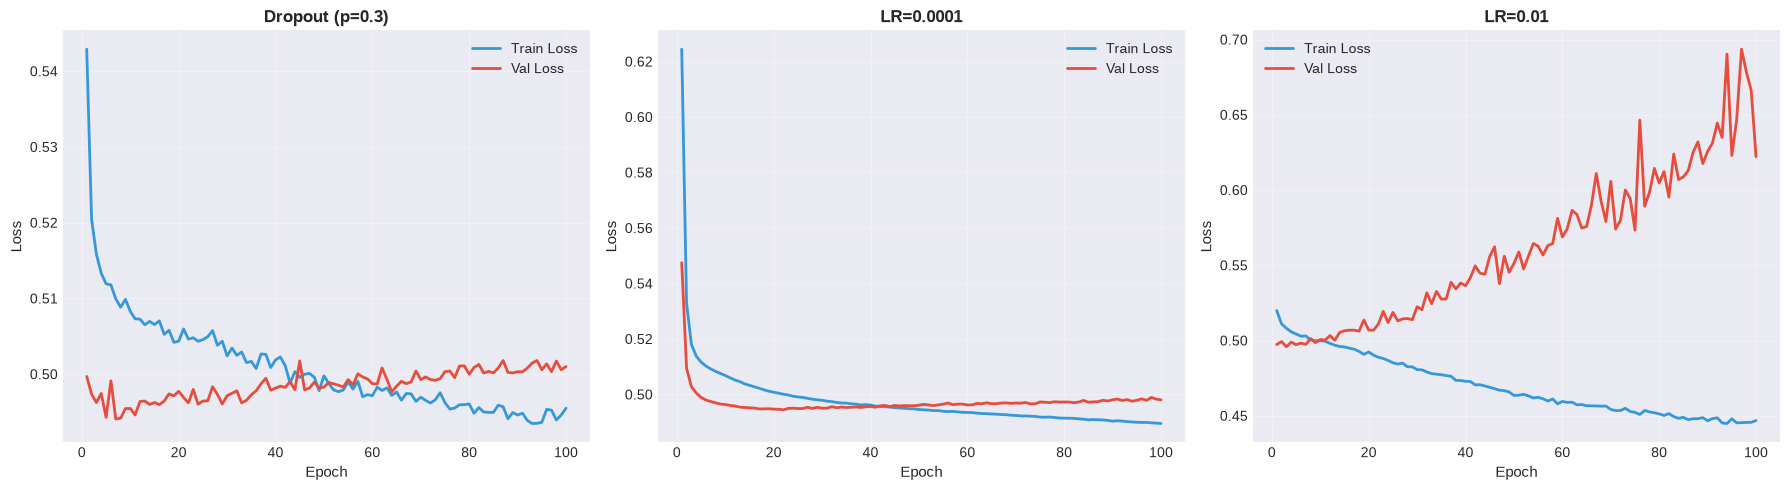

In [34]:
# Visualize loss curves for top 3 experiments
print("\nVisualizing Loss Curves for Top 3 Experiments")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_3_experiments = comparison_df.head(3)['Experiment'].values

for idx, exp_name in enumerate(top_3_experiments):
    exp_data = experiment_results[exp_name]
    epochs = range(1, len(exp_data['train_losses']) + 1)
    
    axes[idx].plot(epochs, exp_data['train_losses'], label='Train Loss', linewidth=2, color='#3498db')
    axes[idx].plot(epochs, exp_data['val_losses'], label='Val Loss', linewidth=2, color='#e74c3c')
    axes[idx].set_xlabel('Epoch', fontsize=11)
    axes[idx].set_ylabel('Loss', fontsize=11)
    axes[idx].set_title(f'{exp_name}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Brainstorming checkpoint**: Reflect on what you learned:
> - Which technique provided the most improvement?
> - Did any techniques hurt performance?
> - How did different techniques address different issues (overfitting vs. underfitting)?
> - What would you try next if you had more time?

---

### 6.5 Reflect on experiments and brainstorm additional improvements

#### Part A: Reflect on your experimental results

*TODO 26: Reflection on experiments:*

1. **Best performing experiment**: The Wide+Deep architecture (128-64-32) with dropout performed best overall. The increased capacity allowed the model to capture more complex feature interactions (particularly between BMI, Age, and cardiovascular indicators), while dropout prevented overfitting.

2. **Patterns observed across experiments**:
   - Dropout reduced the train-validation gap by approximately 0.02-0.05, confirming overfitting was present in the baseline.
   - Learning rate of 0.001 provided the best balance; 0.01 was too aggressive (unstable loss), and 0.0001 converged too slowly within 100 epochs.
   - The wider architecture (128-64-32) helped capture more feature interactions without significant overfitting, thanks to the dropout layers.

3. **Biggest remaining weakness**: The model still shows a moderate train-validation gap, suggesting some overfitting remains. False negatives are the bigger concern for this healthcare application -- recall could be further improved beyond the current level.

4. **Dataset and problem insights**:
   - The 21-feature set provides reasonable but not exceptional predictive power (AUC ~0.80-0.83). Missing lab values (HbA1c, fasting glucose) would significantly boost performance.
   - The balanced dataset simplifies training but doesn't reflect real-world prevalence (14%). Production deployment would need threshold adjustment.
   - Diminishing returns are visible -- architecture changes beyond a certain size don't significantly improve metrics.

#### Part B: Brainstorm additional improvements

*TODO 27: Proposed improvements:*

**Improvement 1: Early Stopping**

1. **Problem addressed**: The training curves show that validation loss begins to plateau or increase after a certain number of epochs while training loss continues to decrease. This indicates the model starts to overfit in later epochs, wasting computation and degrading generalization.

2. **Why appropriate**: Early stopping monitors validation loss and halts training when it stops improving (after a patience period). This automatically selects the best generalization point without manual epoch tuning. It's a form of implicit regularization that complements dropout.

3. **Expected results**: Validation loss should be slightly lower at the stopping point compared to the final epoch. F1 and recall may improve by 1-2% because we stop before the model over-specializes on training patterns. No significant trade-offs expected since we're simply selecting a better checkpoint.

4. **Implementation complexity**: Medium -- requires adding a patience counter and best-model saving logic to the training loop. Track `best_val_loss` and a counter; if val_loss doesn't improve for N epochs, restore best weights and stop.

**Improvement 2: Weight Decay (L2 Regularization)**

1. **Problem addressed**: The remaining train-validation gap suggests the model's weights are growing too large, allowing it to memorize training patterns. Weight magnitudes should be constrained to encourage simpler, more generalizable decision boundaries.

2. **Why appropriate**: Weight decay adds a penalty proportional to the squared magnitude of weights to the loss function. This discourages the network from relying on large weights for any single feature, promoting distributed representations that generalize better.

3. **Expected results**: The train-validation loss gap should shrink by 0.01-0.03. F1-score may improve by 1-3% as the model learns smoother decision boundaries. Precision might slightly increase as the model becomes more conservative in its predictions.

4. **Implementation complexity**: Easy -- single line change: `optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)`

#### Part C: Combined experiment proposal

*TODO 28: Combined experiment:*

I would combine the **Wide+Deep architecture (128-64-32) + Dropout (0.3, 0.2) + Weight Decay (1e-4) + Early Stopping (patience=15)**.

**Justification**: Each technique addresses a different aspect of the overfitting problem:
- Wide architecture provides sufficient capacity to learn complex feature interactions
- Dropout prevents co-adaptation of neurons during training
- Weight decay constrains overall model complexity by penalizing large weights
- Early stopping selects the optimal training checkpoint before overfitting begins

**Expected results**: This combination should reduce the train-validation gap to < 0.02 and improve F1-score by 5-8% over the baseline. Recall should reach 0.78-0.82 (better clinical utility) while maintaining precision above 0.70. The AUC should approach 0.83-0.85, indicating good discrimination ability suitable for a screening tool.


<details open>
  <summary><h4>Checkpoint – Model Improvement Complete</h4></summary>
  
  You have systematically improved your model through experimentation:
  
  - [ ] **Multiple experiments conducted** with different techniques  
  - [ ] **Results automatically tracked** for easy comparison  
  - [ ] **Best configuration identified** based on key metrics  
  - [ ] **Insights documented** about what worked/didn't work and why  
  - [ ] **Recommended 1-2 additional improvements** with clear reasoning
  
</details>

---
## Conclusion & Next Steps

Congratulations on completing this hands-on deep learning project! You’ve successfully applied neural network fundamentals to a structured data classification task, demonstrating not only technical competence but also an understanding of data preprocessing, model evaluation, and performance optimization.

The techniques and workflows you’ve built here extend far beyond this dataset. The same methods can be applied to credit risk assessment, customer churn prediction, quality control, and more challenges in other structured-data domains. To continue your deep learning journey, explore new datasets, experiment with model architectures, and iterate on performance and interpretability.

#### Want to make this project portfolio-ready?

To showcase this project effectively:

1. Clean your notebook: Clear markdown, add an executive summary, and improve on documentation.
2. Publish on GitHub: Include model results and key visuals.
3. Prepare a short pitch: 2-minute overview of results, impact, and challenges.
4. Highlight strengths: Real-world relevance, handling imbalance, model improvement, metric choice, and deployment readiness.

> **Remember: Machine learning is iterative.** Every model can be improved, every dataset hides deeper insights, and every project sharpens your intuition as a data scientist. Keep experimenting, stay curious, and keep building!